# The Dirichlet Problem and Local Martingales

In this notebook we define the Dirichlet problem in $n$ dimensions and its relation to local martingales. We then demonstrate an example of a probabilistic approximation to the solution of the Dirichlet problem in two dimensions.

## The Dirichlet Problem

Let $U \subseteq \mathbb{R}^n$ be an open bounded connected set, with closure $\bar{U}$ and boundary $\partial U$.  
Let $f: U \to \mathbb{R}$ be twice continuously differentiable ($\mathcal{C}^2$) on $U$, and continuous on $\bar{U}$.  
Let $\phi: \partial U \to \mathbb{R}$ be continuous.

We say $f$ solves the Dirichlet problem on $U$ with boundary condition $U$ if  
$\nabla f = 0$ on $U$ and $f = \phi$ on $\partial U$.

## Relation to Local Martingales

Let $(\Omega,\mathcal{F},(\mathcal{F}_t),\mathbb{P})$ be a filtered probability space, and $B^x$ a Brownian motion on this space, started at $x \in U$.  
Define $T^x = \inf\{t \geq 0 : B^x_t \notin U\}$ be the escape time of $B^x$ from $U$.  
Let $X^x_t = f(B^x_t)$ for all $t \in [0,T^x]$.

### Proposition:
$X^x$ is a local martingale on $[0,T^x)$.

### Proof:
By Ito's Formula for $\mathcal{C}^2$ functions:
$$ 
\begin{align*}
    \textrm{d} X^x_t &= \textrm{d} f(B^x_t) \\
    &= \sum_{i=1}^n  \frac{\partial f}{\partial x_i} \big(B^x_t\big) \ \textrm{d} B^x_t 
     + \frac{1}{2} \sum_{i,j=1}^n \frac{\partial^2 f}{\partial x_i \partial x_j} \big(B^x_t\big) \ \textrm{d} B^x_t \\
    &= \sum_{i=1}^n  \frac{\partial f}{\partial x_i} \big(B^x_t\big) \ \textrm{d} B^x_t 
\end{align*}
$$
since $f$ solves the Dirichlet problem. Hence $X^x$ is a stochastic integral against a Brownian motion, so is a local martingale.

### Proposition:
For all $x \in U$, $\mathbb{E}[\phi(B^x_{T^x})] = f(x)$.

### Proof:
Since $U$ is bounded, $T^x$ is almost surely finite.  
Hence there is a reparametrisation $\gamma : [0,T^x) \to [0,\infty)$ such that $X^x_t = Y^x_{\gamma(t)}$ with $Y^x$ a martingale.  
Further, since $f$ is continuous on a compact set, it is bounded, so $Y^x$ is a bounded martingale.  
Hence by the martingale convergence theorem:
$$
\begin{align*}
    \mathbb{E}[\phi(B^x_{T^x})]
    &= \mathbb{E}[f(B^x_{T^x})] \\
    &= \mathbb{E}[X^x_{T^x}] \\
    &= \mathbb{E}[Y^x_\infty] \\
    &= \mathbb{E}[Y^x_0] \\
    &= \mathbb{E}[X^x_0] \\
    &= \mathbb{E}[f(B^x_0)] \\
    &= \mathbb{E}[f(x)] \\
    &= f(x).
\end{align*}
$$

## Implications

The above propositions prove that the solution is uniquely determined by the boundary condition $\phi$. Moreover, they suggest a way to approximate the solution of the dirichlet problem $f$ by Monte Carlo simulation with Brownian motion:

$$
f(x) = \mathbb{E}[\phi(B^x_{T^x})] \approx \sum_{m=1}^M \phi(B^{x,m}_{T^{x,m}})
$$

by the strong law of large numbers, where $M$ is large and $B^{x,m}$ are independent Brownian motions started from $x$.

## An Example

Working in two dimensions, first we choose a suitable region $U \subset \mathbb{R}^2$, and a function $\phi$ defined on $\partial U$:

$$
    U = A \setminus B
$$

where $A$ and $B$ are the nested circles

$$
    A = \{(x,y) : (x-1)^2 + y^2 < 5^2\},
$$

$$
    B = \{(x,y) : x^2 + y^2 < 2^2\}.
$$

The boundary condition $\phi$ is given by

$$
    \phi(x,y) = x^2 + y +10
$$

where $(x,y) \in \partial U$. Figure TODO shows $U$, $\partial U$ and $\phi$.

In [220]:
import dirichlet_problem_local_martingales as dplm
import importlib
importlib.reload(dplm)

import numpy as np
import matplotlib.pyplot as plt
%config InlineBackend.print_figure_kwargs = {'bbox_inches':None}
from mpl_toolkits.mplot3d import Axes3D

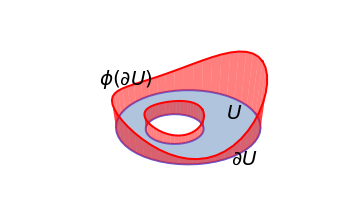

In [221]:
num_samples = 50

dU = dplm.get_region_boundary(num_samples)
phi = dplm.phi
boundary_values = dplm.apply_to_coords(dU, phi)

dplm.plot_region_and_boundary_condition(dU, boundary_values, num_samples)

Next we need to be able to simulate Brownian motions started from any $x \in U$.

In [222]:
B = dplm.sim_2d_bm((3,0), 10, 100)
B = dplm.up_to_escape(B)

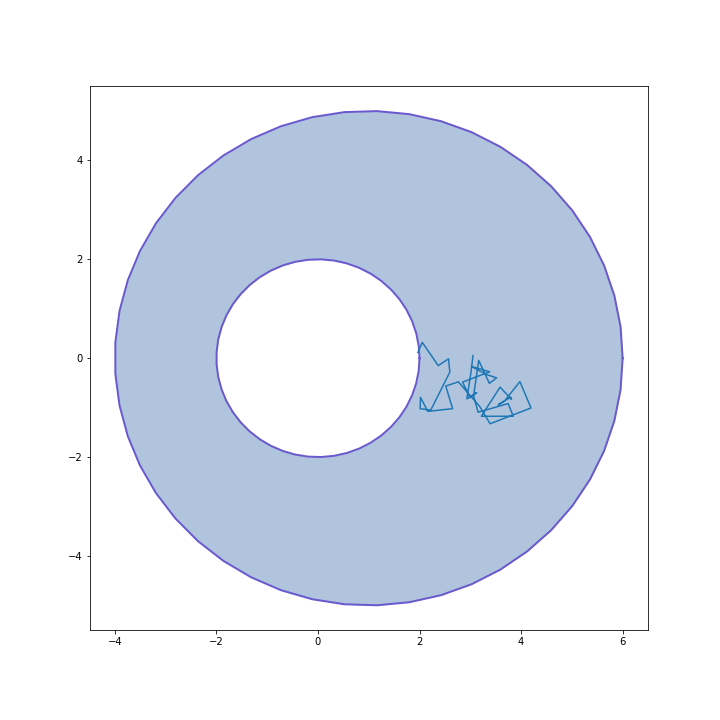

In [224]:
dplm.plot_single_bm_path(dU, 10, num_samples)

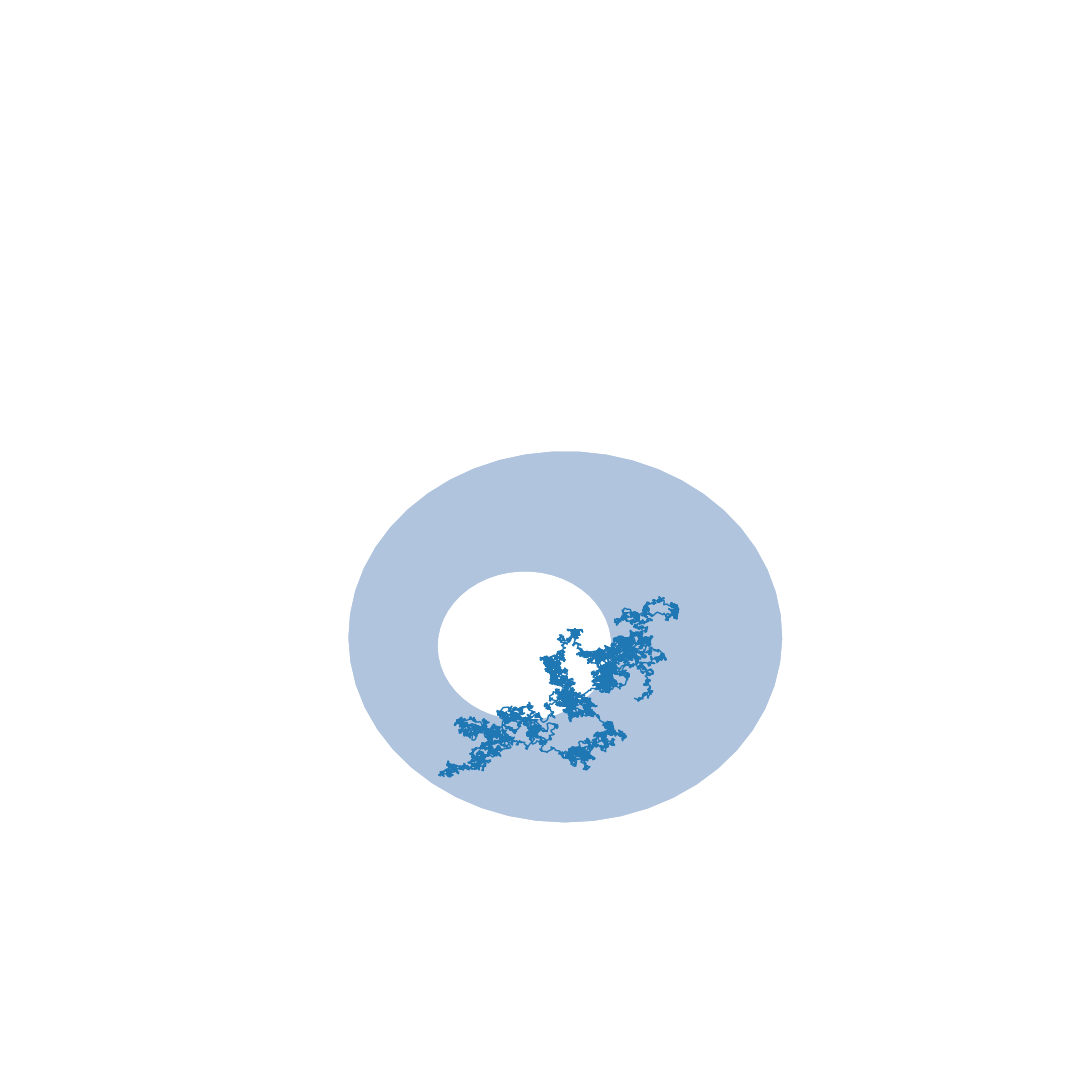

In [137]:

fig = plt.figure(figsize=(15,15))
ax = fig.add_subplot(111, projection='3d')
ax.add_collection3d(plt.fill_between(dU[:,0], dU[:,1], 0, color='lightsteelblue', linewidth=0))
plt.plot(B[:,0],B[:,1], zorder=10)
ax.set_xlim([-4,6])
ax.set_ylim([-5,5])
ax.set_zlim([0,40])
plt.axis('off')

# viewpoint
ax.view_init(elev=60, azim=250)


plt.show()